# Spatiotemporal Analysis
February 23, 2024

### Further spatiotemporal characterization of deconvolved chromatin bins

1. What is the timing of these cycling bins? Which cell phases?
- An easy way to start this analysis is check for the cycling bins, do they correlate well with the cycling gene expression?

2. What is the location of the cell cycling bins?
And, this may improve the signal, does categorizing the bins as small fragment or nucleosome sized, or promoter vs gene body help with this analysis?

#### Procedure for temporal analysis correlation with gene expression
1. Compute the index (in f) of the PTR values. One for the peak, and one for the trough.
    - Start with reading in the deconvolved f values, but eventually we can build this into the deconvolution algorithm.
2. Plot a scatter plot of the peak to trough locations with the gene expression peak to trough locations.
    - The data points of the scatter plot: to be determined.
    - Calculate a correlation
    - How does the Spellman genes hold up to this analysis?
    


In [1]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [5]:
from src.config import load_yl_rg1_vst_config
from cc_src.chromatin_model import ChromatinModel


config = load_yl_rg1_vst_config(1)
chromatin_model = ChromatinModel(config)

chromatin_model.load_mnase_gene('CDC5')

Loading MNase reads for YMR001C/CDC5...Done.


In [8]:
chromatin_model.create_deconvolution_bins()

Unflattened the input data is of shape: (16, 16, 50)
The size of our input data, G is: (16, 800)


In [342]:
chromatin_model.deconvolve_find_optimal_gamma()

Running the find optimal gamma procedure...
  ... The base fitting norm (rn) with no smoothing (gamma=0) is: 5.0503
  ... Searching for an optimal gamma value in the boundaries: [0.0001, 0.0100]
  ...  search left, rn_goal = 5.1303, rate = 1.6
  ...  search right, rn_goal = 7.0704, rate = 40.0
  ... rn range: [5.1853, 5.3429]
  ... search gamma in [0.0001 0.0100] for elbow
  ...   gm = 0.0001, rn = 5.1853, rate = 2.67, time = 00:03:52.94
  ...   gm = 0.0011, rn = 5.2226, rate = 3.41, time = 00:04:51.50
  ...   gm = 0.0021, rn = 5.2383, rate = 3.72, time = 00:05:49.11
  ...   gm = 0.0031, rn = 5.2559, rate = 4.07, time = 00:06:46.41
  ...   gm = 0.0041, rn = 5.2744, rate = 4.44, time = 00:07:45.41
  ...   gm = 0.0050, rn = 5.2847, rate = 4.64, time = 00:08:43.40
  ...   gm = 0.0060, rn = 5.2962, rate = 4.87, time = 00:09:42.37
  ...   gm = 0.0070, rn = 5.3143, rate = 5.23, time = 00:10:40.65
  ...   gm = 0.0080, rn = 5.3252, rate = 5.44, time = 00:11:39.26
  ...   gm = 0.0090, rn = 5.33

In [343]:
from src.model import Model
gene_name = 'CDC5'
ge_model = Model(config, gene_name)
ge_model.deconvolve_find_optimal_gamma()

In [344]:
chromatin_model.compute_ptr()

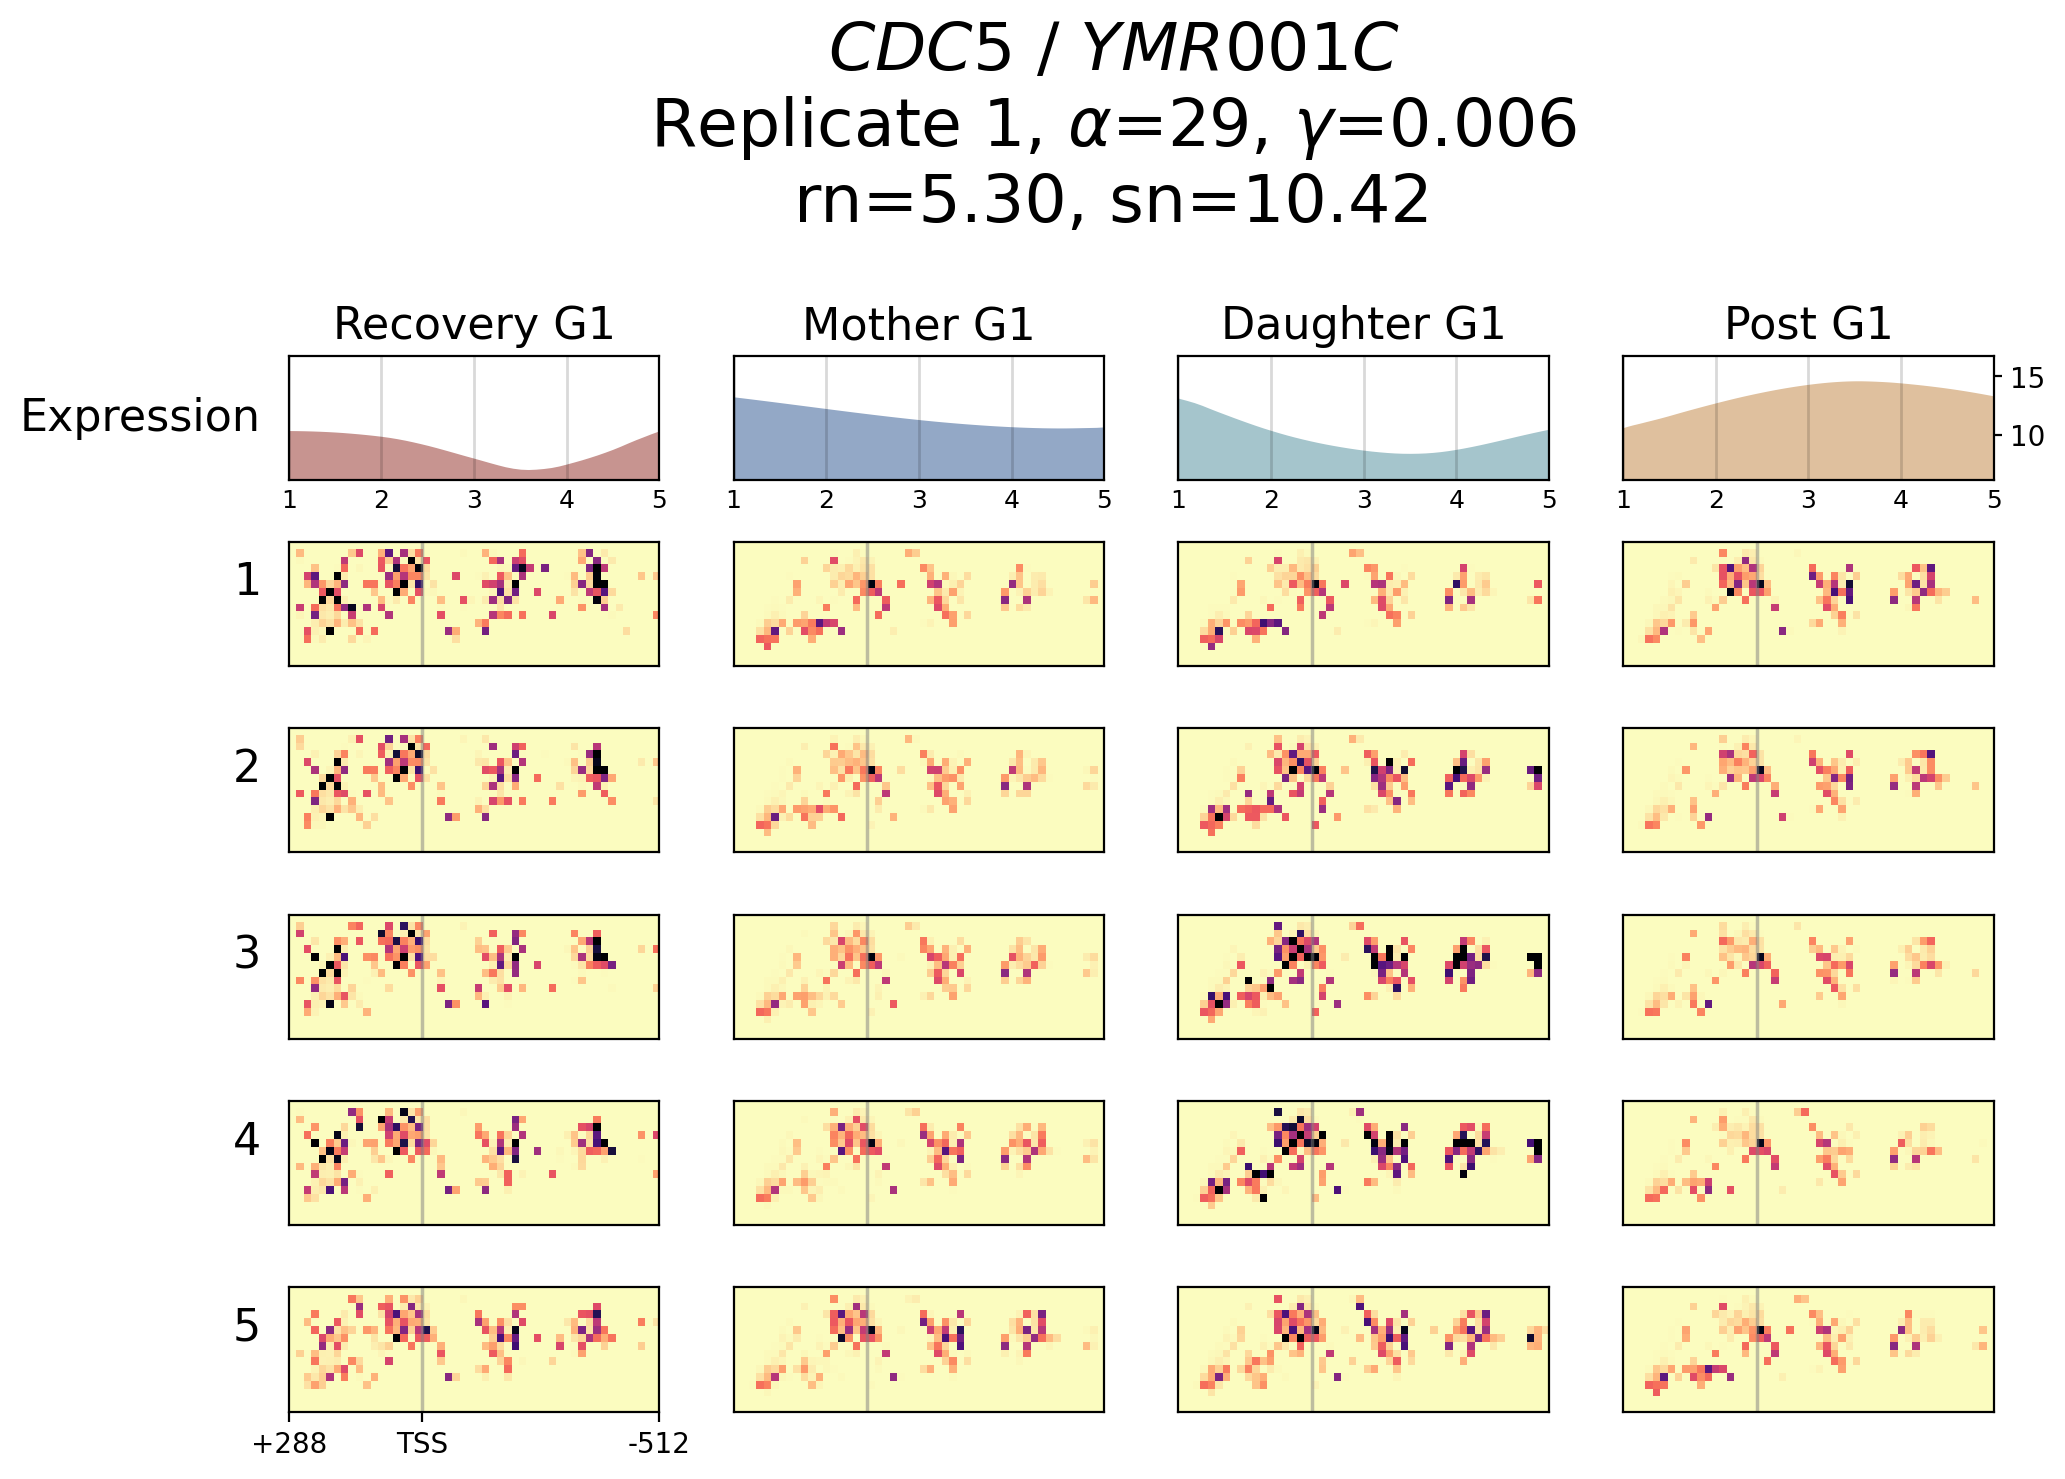

In [345]:
fig = chromatin_model.create_deconvolution_plots_abbreviated_flipped(ge_model=ge_model)

In [362]:
chromatin_model.compute_ptr()

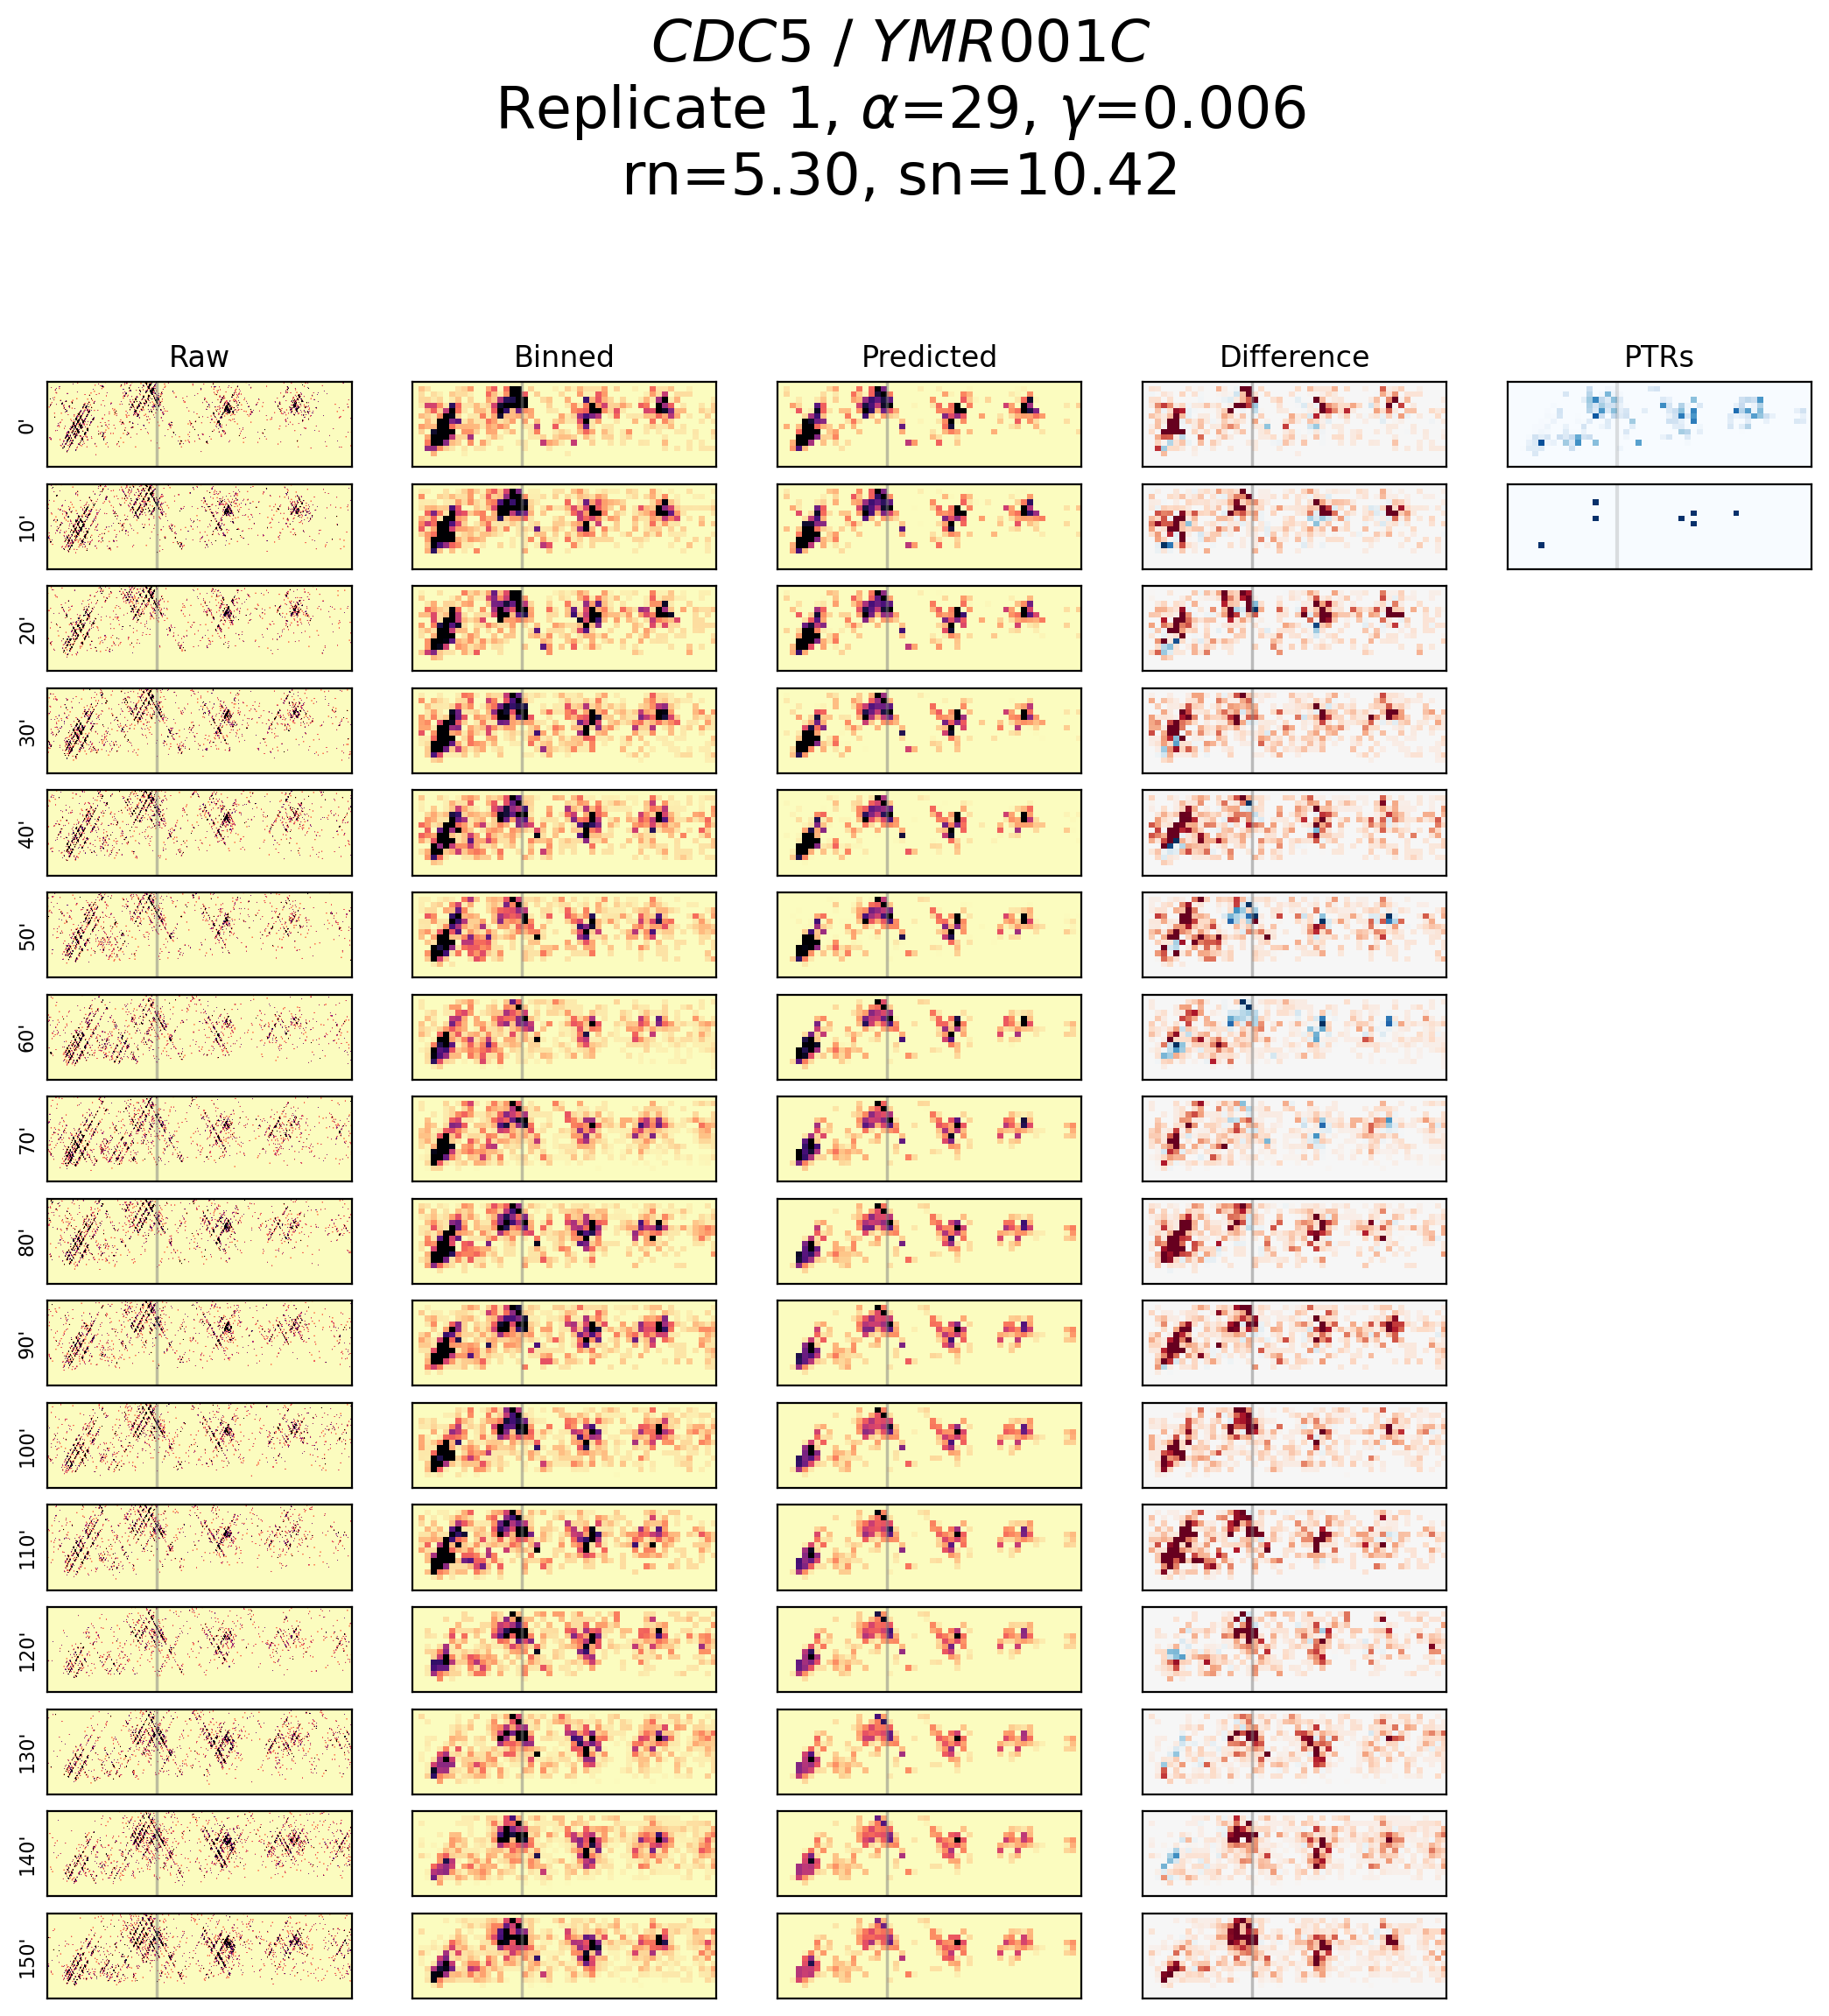

In [363]:
fig = chromatin_model.plot_prediction_comparison()

In [348]:
indices = np.arange(m)[chromatin_model.f_ranks < 7]

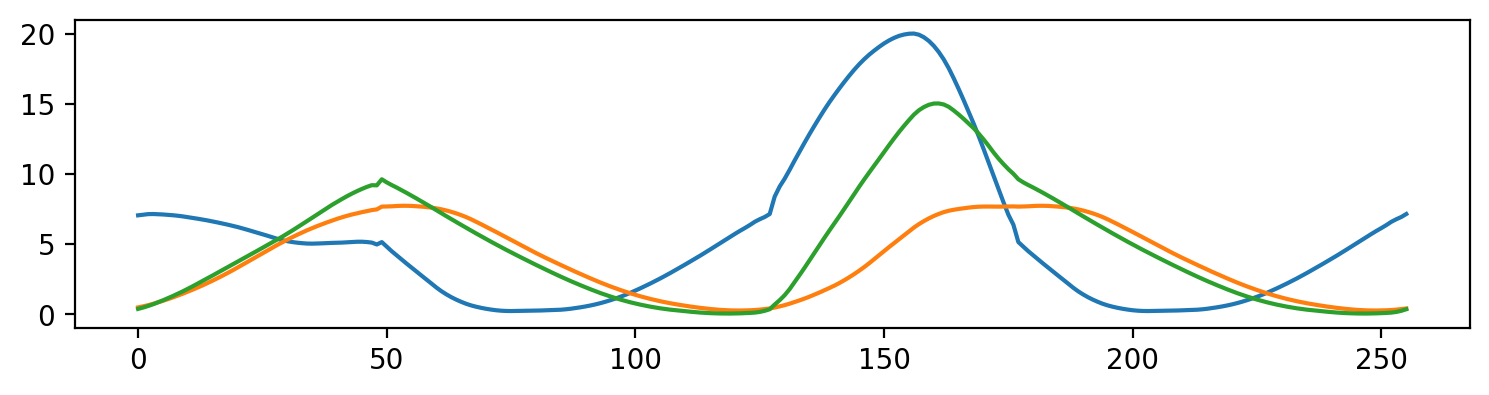

In [352]:
f = chromatin_model.solver.f.value
f_k_values = f[:, indices]
f_k_values.shape

fig = plt.figure(figsize=(9, 2))
plt.plot(f_k_values[np.concatenate([cg1_indices, dg1_indices]), 0])
plt.plot(f_k_values[np.concatenate([cg1_indices, dg1_indices]), 1])
plt.plot(f_k_values[np.concatenate([cg1_indices, dg1_indices]), 3])

# Get the timepoints for CG1-postG1-DG1-postG1
# and plot these

# We'll do the same with gene expression and see if we can plot
# these aligned with another
# We may need to think about how to do this analysis further.
#  .....

deconv_model = chromatin_model.deconv_model
cg1_indices = np.concatenate([deconv_model.config.phase_columns['CG1'], 
    deconv_model.config.phase_columns['postG1']])
dg1_indices = np.concatenate([deconv_model.config.phase_columns['DG1'], 
    deconv_model.config.phase_columns['postG1']])
 
# Interesting, we are seeing differences in the offset for occupancy for different regions 
# in the chromatin, some places are being occupied first...

([], [])

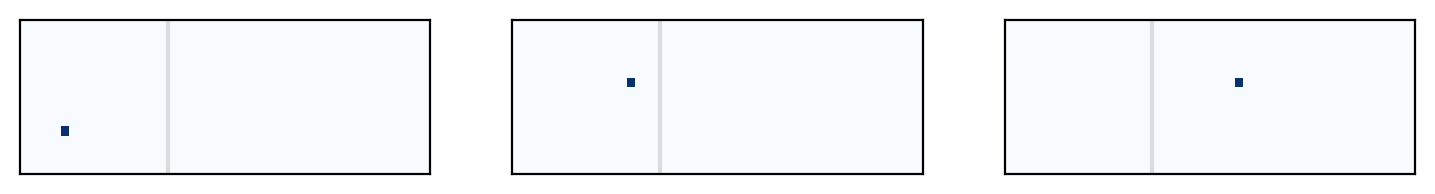

In [359]:
plt.figure(figsize=(9, 1))
plt.subplot(1, 3, 1)
plt.imshow((f_ranks == 0).reshape(chromatin_model.image_shape), origin='lower', 
           cmap='Blues', aspect='auto', extent=chromatin_model.bin_extents)

plt.xlim(plt.xlim()[1], plt.xlim()[0])
plt.axvline(chromatin_model.computed_plus_one, c='gray', alpha=0.25)
plt.xticks([])
plt.yticks([])

plt.subplot(1, 3, 2)
plt.imshow((f_ranks == 1).reshape(chromatin_model.image_shape), origin='lower', 
           cmap='Blues', aspect='auto', extent=chromatin_model.bin_extents)
plt.xlim(plt.xlim()[1], plt.xlim()[0])
plt.axvline(chromatin_model.computed_plus_one, c='gray', alpha=0.25)
plt.xticks([])
plt.yticks([])

plt.subplot(1, 3, 3)
plt.imshow((f_ranks == 3).reshape(chromatin_model.image_shape), origin='lower', 
           cmap='Blues', aspect='auto', extent=chromatin_model.bin_extents)
plt.xlim(plt.xlim()[1], plt.xlim()[0])
plt.axvline(chromatin_model.computed_plus_one, c='gray', alpha=0.25)
plt.xticks([])
plt.yticks([])